# Cold-chain synthetic dataset report

Loads a dataset produced by `python -m data.generate` and renders coverage,
label balance, spoilage-risk trajectory, delivery statistics, action histograms,
and disruption/health diagnostics.

Set `DATASET_DIR` in the next cell to the folder that contains `episode_*.pkl`
and `manifest.json`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "dataset.py").exists():
            return candidate
    raise RuntimeError("could not locate project root (data/dataset.py not found)")


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data.dataset import ColdChainDataset

DATASET_DIR = PROJECT_ROOT / "data" / "dataset"

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
dataset = ColdChainDataset.from_dir(DATASET_DIR)
manifest = dataset.manifest
print(f"episodes: {len(dataset)}")
print(f"master_seed: {manifest.get('master_seed')}")
print(f"dataset_sha256: {manifest.get('dataset_sha256', '')[:16]}...")
if manifest.get("library_versions"):
    versions = pd.Series(manifest["library_versions"], name="version")
    display(versions.to_frame())

episodes: 100
master_seed: 0
dataset_sha256: 6e4db73ed5fce616...


,version
gymnasium,1.2.2
networkx,3.6.1
numpy,2.5.0
pettingzoo,1.26.1
ray,2.55.1
torch,2.12.1
torch-geometric,2.8.0


## Overview

In [3]:
episode_rows = []
for ep in dataset:
    episode_rows.append({
        "episode_id": ep.episode_id,
        "fruit": ep.fruit_type.value,
        "weather": ep.ambient_weather.value,
        "ambient_temp_c": ep.ambient_temp_c,
        "source": ep.source_node,
        "target": ep.target_node,
        "n_steps": len(ep.steps),
        "final_label": ep.final_label,
        "delivered": bool(ep.steps and ep.steps[-1].delivered),
    })
episodes_df = pd.DataFrame(episode_rows)

overview = pd.DataFrame({
    "value": [
        len(episodes_df),
        episodes_df["n_steps"].mean(),
        episodes_df["n_steps"].min(),
        episodes_df["n_steps"].max(),
        episodes_df["ambient_temp_c"].mean(),
        episodes_df["ambient_temp_c"].std(),
        episodes_df["final_label"].mean(),
        episodes_df["delivered"].mean(),
    ],
}, index=[
    "n_episodes",
    "mean_episode_length",
    "min_episode_length",
    "max_episode_length",
    "mean_ambient_temp_c",
    "std_ambient_temp_c",
    "spoiled_fraction",
    "delivered_fraction",
])
overview.round(3)

,value
n_episodes,100.000
mean_episode_length,12.280
min_episode_length,3.000
max_episode_length,20.000
mean_ambient_temp_c,20.537
std_ambient_temp_c,5.519
spoiled_fraction,0.450
delivered_fraction,0.310


## Coverage — fruits, weather, source, target

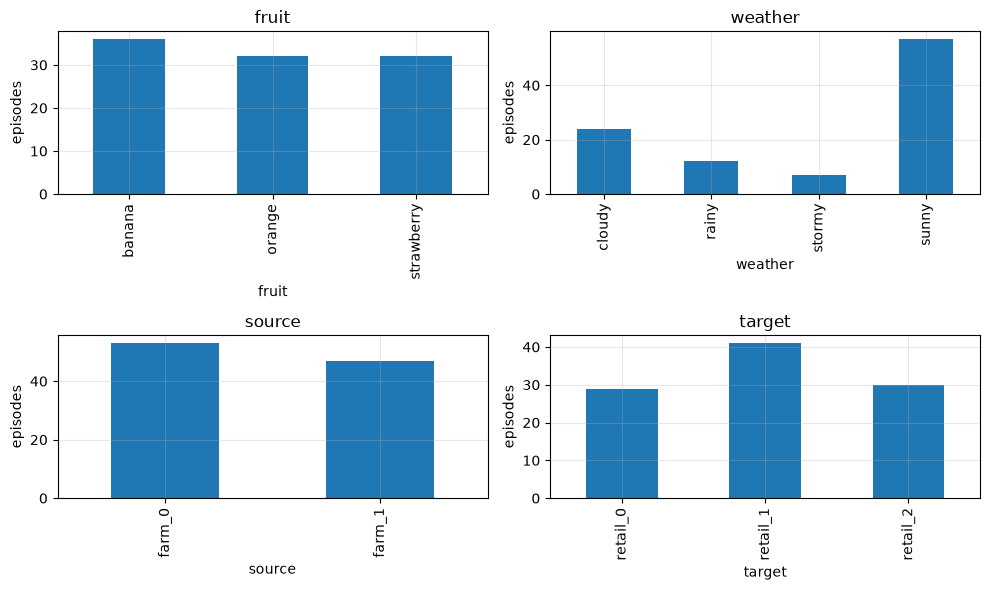

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, col in zip(axes.flatten(), ["fruit", "weather", "source", "target"]):
    episodes_df[col].value_counts().sort_index().plot.bar(ax=ax, color="tab:blue")
    ax.set_title(col)
    ax.set_ylabel("episodes")
fig.tight_layout()
plt.show()

## Label distribution

In [5]:
overall = episodes_df["final_label"].value_counts().sort_index()
overall.index = ["fresh (0)", "spoiled (1)"][:len(overall)]

by_fruit = (
    episodes_df.groupby("fruit")["final_label"]
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={0: "fresh", 1: "spoiled"})
    .sort_index()
)
by_fruit["spoiled_rate"] = by_fruit["spoiled"] / by_fruit.sum(axis=1)

by_weather = (
    episodes_df.groupby("weather")["final_label"]
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={0: "fresh", 1: "spoiled"})
    .sort_index()
)
by_weather["spoiled_rate"] = by_weather["spoiled"] / by_weather.sum(axis=1)

print("overall label counts:")
print(overall)
print()
display(by_fruit.round(3))
display(by_weather.round(3))

overall label counts:
fresh (0)      55
spoiled (1)    45
Name: count, dtype: int64



final_label,fresh,spoiled,spoiled_rate
fruit,,,
banana,14,22,0.611
orange,29,3,0.094
strawberry,12,20,0.625


final_label,fresh,spoiled,spoiled_rate
weather,,,
cloudy,11,13,0.542
rainy,11,1,0.083
stormy,4,3,0.429
sunny,29,28,0.491


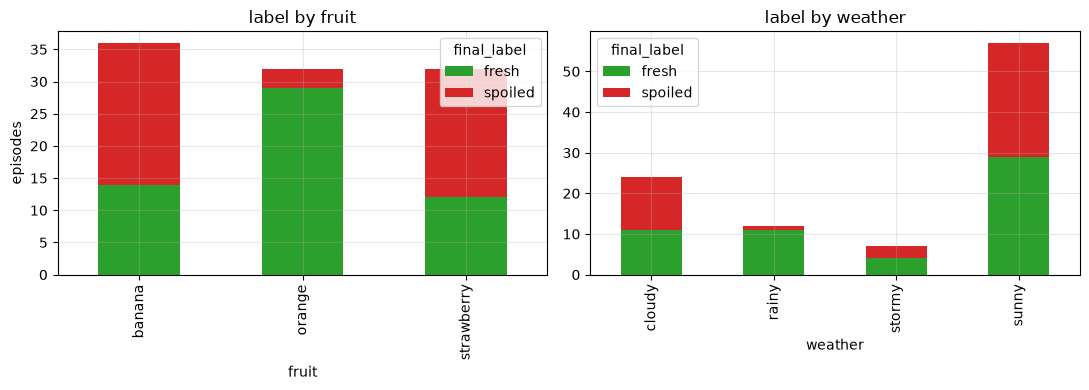

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
by_fruit[["fresh", "spoiled"]].plot.bar(stacked=True, ax=axes[0], color=["tab:green", "tab:red"])
axes[0].set_title("label by fruit")
axes[0].set_ylabel("episodes")
by_weather[["fresh", "spoiled"]].plot.bar(stacked=True, ax=axes[1], color=["tab:green", "tab:red"])
axes[1].set_title("label by weather")
fig.tight_layout()
plt.show()

## Delivery rate by fruit

,delivered_rate,count
fruit,,
banana,0.222,36
orange,0.438,32
strawberry,0.281,32


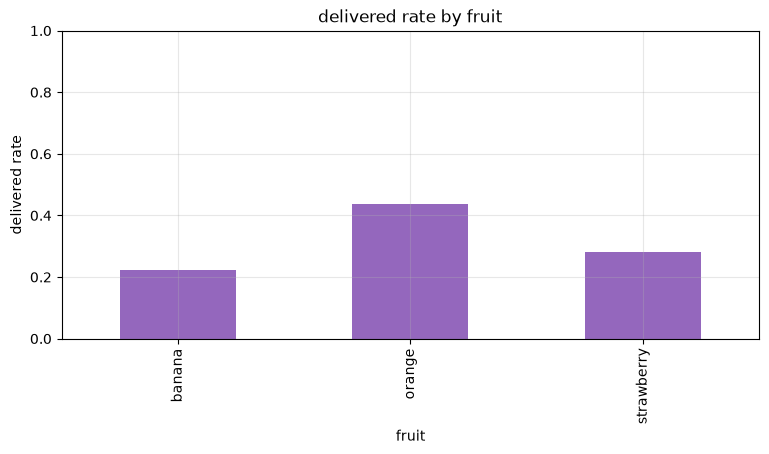

In [7]:
delivery_by_fruit = episodes_df.groupby("fruit")["delivered"].agg(["mean", "count"])
delivery_by_fruit = delivery_by_fruit.rename(columns={"mean": "delivered_rate"})
display(delivery_by_fruit.round(3))

fig, ax = plt.subplots()
delivery_by_fruit["delivered_rate"].plot.bar(ax=ax, color="tab:purple")
ax.set_ylim(0, 1)
ax.set_ylabel("delivered rate")
ax.set_title("delivered rate by fruit")
plt.show()

## Spoilage risk trajectory (progress-normalized)

,mean,std,count
rel_bin,,,
0,0.057,0.052,164
1,0.135,0.089,116
2,0.185,0.108,134
3,0.270,0.137,117
4,0.337,0.170,105
5,0.385,0.209,138
6,0.454,0.232,127
7,0.513,0.250,124
8,0.571,0.253,126


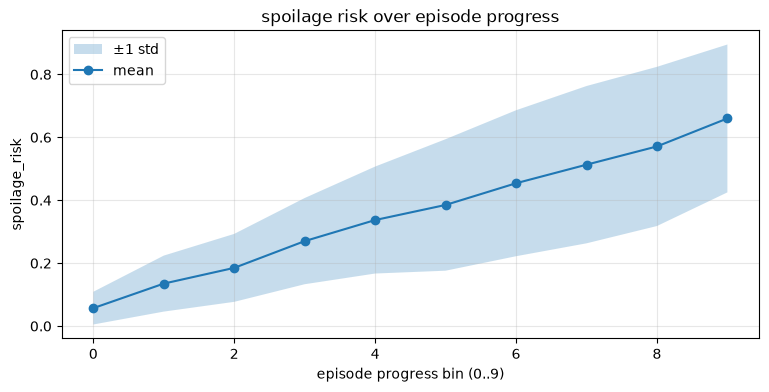

In [8]:
BINS = 10
step_rows = []
for ep in dataset:
    n = len(ep.steps)
    for i, step in enumerate(ep.steps):
        rel_bin = min(BINS - 1, i * BINS // n) if n else 0
        step_rows.append({
            "episode_id": ep.episode_id,
            "fruit": ep.fruit_type.value,
            "weather": ep.ambient_weather.value,
            "tick": step.tick,
            "rel_bin": rel_bin,
            "spoilage_risk": step.spoilage_risk,
            "sensor_temperature_c": step.sensor_temperature_c,
            "energy_usage": step.energy_usage,
            "delivered": step.delivered,
            "n_disruptions": len(step.active_disruptions),
        })
steps_df = pd.DataFrame(step_rows)

overall_traj = steps_df.groupby("rel_bin")["spoilage_risk"].agg(["mean", "std", "count"]).round(3)
display(overall_traj)

fig, ax = plt.subplots()
ax.fill_between(overall_traj.index,
                overall_traj["mean"] - overall_traj["std"],
                overall_traj["mean"] + overall_traj["std"],
                alpha=0.25, label="±1 std")
ax.plot(overall_traj.index, overall_traj["mean"], marker="o", label="mean")
ax.set_xlabel(f"episode progress bin (0..{BINS - 1})")
ax.set_ylabel("spoilage_risk")
ax.set_title("spoilage risk over episode progress")
ax.legend()
plt.show()

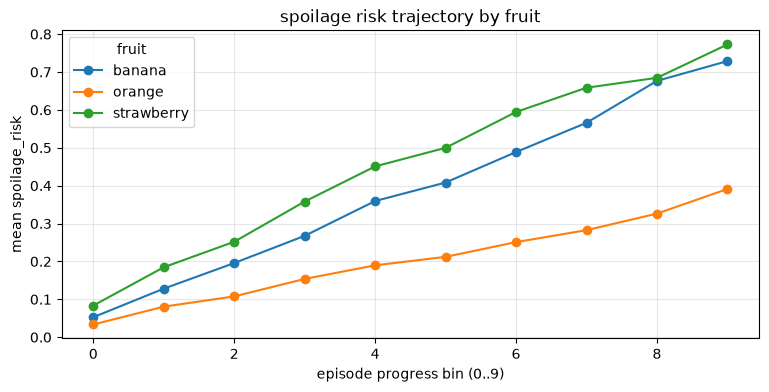

In [9]:
per_fruit_traj = steps_df.groupby(["fruit", "rel_bin"])["spoilage_risk"].mean().unstack("fruit")
fig, ax = plt.subplots()
per_fruit_traj.plot(ax=ax, marker="o")
ax.set_xlabel(f"episode progress bin (0..{BINS - 1})")
ax.set_ylabel("mean spoilage_risk")
ax.set_title("spoilage risk trajectory by fruit")
plt.show()

## Sensor temperature distribution by fruit

,count,mean,std,min,25%,50%,75%,max
fruit,,,,,,,,
banana,462.0,1.55,9.72,-19.36,-6.21,1.67,8.92,25.54
orange,356.0,1.32,9.53,-21.18,-5.72,0.94,8.67,23.52
strawberry,410.0,1.39,9.70,-21.20,-5.80,1.38,9.07,21.57


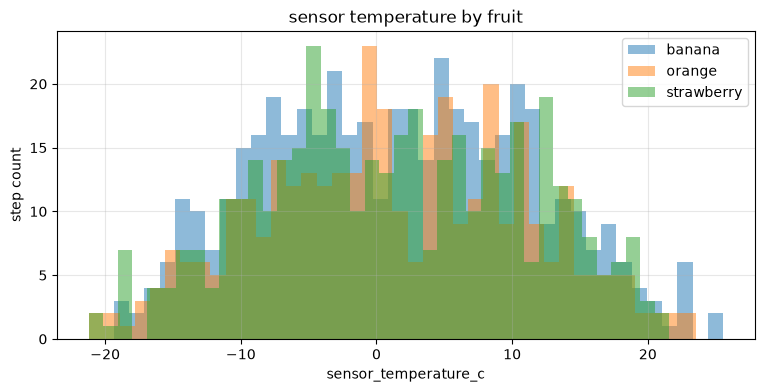

In [10]:
temp_stats = steps_df.groupby("fruit")["sensor_temperature_c"].describe().round(2)
display(temp_stats)

fig, ax = plt.subplots()
for fruit, group in steps_df.groupby("fruit"):
    ax.hist(group["sensor_temperature_c"], bins=40, alpha=0.5, label=fruit)
ax.set_xlabel("sensor_temperature_c")
ax.set_ylabel("step count")
ax.set_title("sensor temperature by fruit")
ax.legend()
plt.show()

## Actions

,routing,delivery,spoilage_pred
0,298,300,398
1,309,315,407
2,305,314,423
3,316,299,0


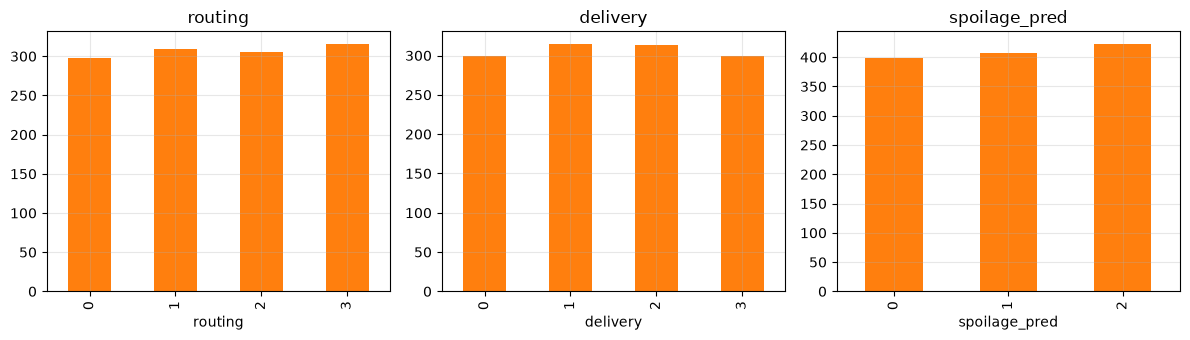

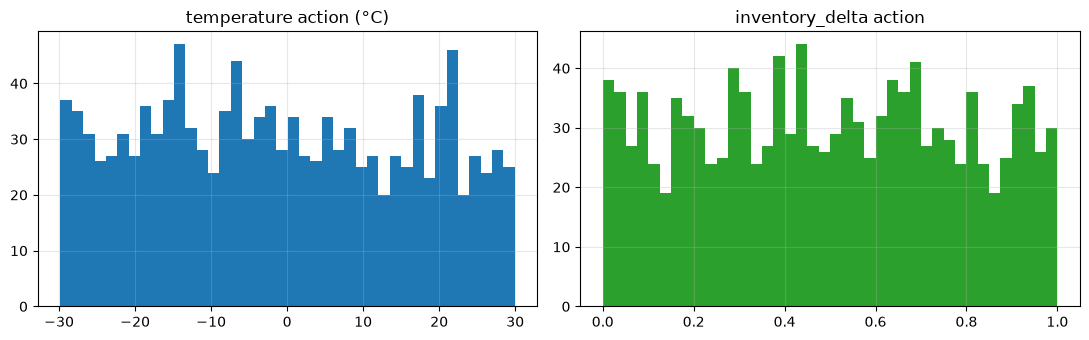

,temperature,inventory_delta
count,1228.000,1228.000
mean,-0.987,0.495
std,17.114,0.287
min,-29.819,0.000
25%,-15.304,0.261
50%,-2.061,0.493
75%,14.283,0.729
max,29.942,1.000


In [11]:
action_rows = []
for ep in dataset:
    for step in ep.steps:
        a = step.actions
        action_rows.append({
            "routing": int(a["routing"]),
            "delivery": int(a["delivery"]),
            "spoilage_pred": int(a["spoilage"]),
            "temperature": float(np.asarray(a["temperature"]).flatten()[0]),
            "inventory_delta": float(np.asarray(a["inventory"]).flatten()[0]),
        })
actions_df = pd.DataFrame(action_rows)

discrete_stats = pd.DataFrame({
    col: actions_df[col].value_counts().sort_index()
    for col in ["routing", "delivery", "spoilage_pred"]
}).fillna(0).astype(int)
display(discrete_stats)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, ["routing", "delivery", "spoilage_pred"]):
    actions_df[col].value_counts().sort_index().plot.bar(ax=ax, color="tab:orange")
    ax.set_title(col)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(actions_df["temperature"], bins=40, color="tab:blue")
axes[0].set_title("temperature action (°C)")
axes[1].hist(actions_df["inventory_delta"], bins=40, color="tab:green")
axes[1].set_title("inventory_delta action")
fig.tight_layout()
plt.show()

display(actions_df[["temperature", "inventory_delta"]].describe().round(3))

## Disruptions

active-disruption counts across all steps:
type
increased_transit_time    287
blocked_node              175
risk_flag                  49
Name: count, dtype: int64

episodes with ≥1 active disruption: 41 / 100


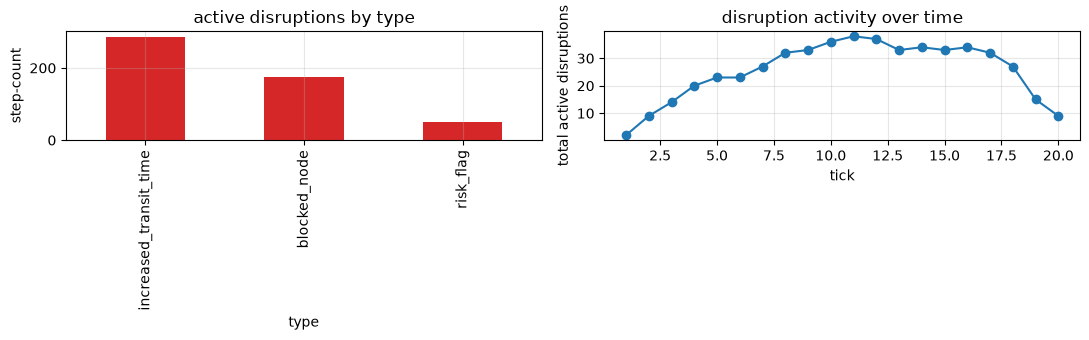

In [12]:
disruption_rows = []
for ep in dataset:
    for step in ep.steps:
        for d in step.active_disruptions:
            disruption_rows.append({
                "episode_id": ep.episode_id,
                "tick": step.tick,
                "type": d.type.value,
                "target": d.target,
            })
disruptions_df = pd.DataFrame(disruption_rows)

if disruptions_df.empty:
    print("no disruptions in dataset")
else:
    type_counts = disruptions_df["type"].value_counts()
    print("active-disruption counts across all steps:")
    print(type_counts)

    episodes_with = disruptions_df["episode_id"].nunique()
    print(f"\nepisodes with ≥1 active disruption: {episodes_with} / {len(dataset)}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    type_counts.plot.bar(ax=axes[0], color="tab:red")
    axes[0].set_title("active disruptions by type")
    axes[0].set_ylabel("step-count")

    disruptions_df.groupby("tick").size().plot(ax=axes[1], marker="o")
    axes[1].set_xlabel("tick")
    axes[1].set_ylabel("total active disruptions")
    axes[1].set_title("disruption activity over time")
    fig.tight_layout()
    plt.show()

## Energy usage

,energy_usage
count,1228.000
mean,1.938
std,1.016
min,0.004
25%,1.167
50%,1.905
75%,2.734
max,4.801


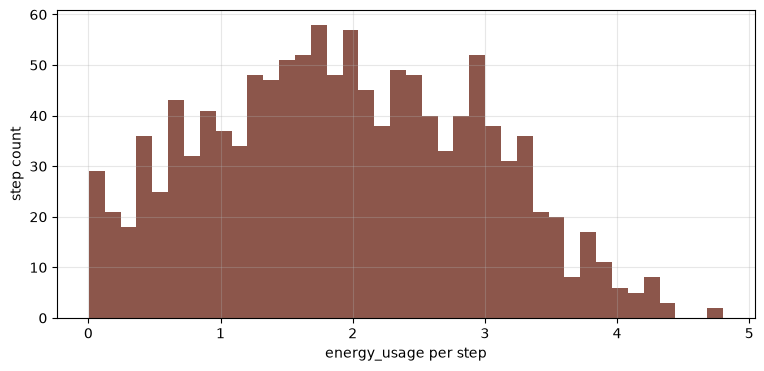

In [13]:
display(steps_df["energy_usage"].describe().round(3).to_frame())

fig, ax = plt.subplots()
ax.hist(steps_df["energy_usage"], bins=40, color="tab:brown")
ax.set_xlabel("energy_usage per step")
ax.set_ylabel("step count")
plt.show()

## Observation health (NaN / Inf)

In [14]:
health_rows = []
for ep in dataset:
    for step in ep.steps:
        for agent, arr in step.observations.items():
            health_rows.append({
                "agent": agent,
                "has_nan": bool(np.isnan(arr).any()),
                "has_inf": bool(np.isinf(arr).any()),
                "min": float(arr.min()),
                "max": float(arr.max()),
            })
health_df = pd.DataFrame(health_rows)

summary = health_df.groupby("agent").agg(
    steps=("has_nan", "size"),
    nan_steps=("has_nan", "sum"),
    inf_steps=("has_inf", "sum"),
    obs_min=("min", "min"),
    obs_max=("max", "max"),
).round(3)
display(summary)

,steps,nan_steps,inf_steps,obs_min,obs_max
agent,,,,,
delivery,1228,0,0,0.000,18.000
inventory,1228,0,0,0.000,27.000
routing,1228,0,0,0.000,3.000
spoilage,1228,0,0,-21.198,25.536
temperature,1228,0,0,-29.819,29.942


## Train/val split preview

In [15]:
train, val = dataset.train_val_split(val_fraction=0.2, seed=0)
print(f"train: {len(train)} episodes | val: {len(val)} episodes")
print(f"train ids sample: {list(train.episode_ids())[:10]}")
print(f"val ids: {list(val.episode_ids())}")

train: 80 episodes | val: 20 episodes
train ids sample: [0, 1, 2, 3, 4, 6, 7, 12, 14, 15]
val ids: [5, 8, 9, 10, 11, 13, 16, 20, 27, 36, 37, 52, 72, 75, 81, 82, 83, 90, 93, 94]
